# Defects and diffusion

A perfect crystal conducts nothing and ages not at all. Everything a material
does slowly — creep, sintering, ionic conduction, radiation damage, the
degradation of a battery cathode over a thousand cycles — happens because atoms
move, and atoms move through defects.

This tutorial builds a vacancy, computes what it costs to make and what it costs
to move, and ends at the quantity a defect chemist actually reports: formation
energy against Fermi level.

The migration barrier at the end comes out at **0.754 eV** against a literature
value of about 0.70 eV for vacancy migration in fcc copper, and the formation
energy at **1.314 eV** against roughly 1.3 eV measured by positron annihilation.
Both from a potential that took no download and no training set.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 213   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Copper, at its measured room-temperature lattice parameter. One material is
enough: a defect calculation is about one host and the many ways to break it.

In [2]:
copper = mv.datasets.metals(["Cu"])
mv.pp.describe(copper)

copper.obs[["name", "formula", "nsites", "lattice_parameter"]]

,name,formula,nsites,lattice_parameter
0,Cu,Cu,4,3.6149


### Two ways to deform a cell before you break it

`mv.pp.supercell` and `mv.pp.strain` both deposit a **variant** rather than
replacing the input, so the original stays available. A supercell is what gives
a defect room not to interact with its own periodic image; a strained cell is
what elastic constants and deformation potentials are computed on.

In [3]:
mv.pp.supercell(copper, (2, 2, 2))
mv.pp.strain(copper, amount=0.02)

mv.variants(copper)

['input', 'supercell_2x2x2', 'strained']

In [4]:
[len(s) for s in mv.structures(copper, "supercell_2x2x2")],     round(mv.structures(copper, "strained")[0].lattice.a, 4)

([32], 3.6872)

## Enumerating the defects

`mv.pp.defects` builds a supercell and removes one atom from each
**symmetrically inequivalent** site. In fcc copper every site is equivalent, so
a 2×2×2 supercell of the conventional cell — 32 atoms — yields exactly one
vacancy, not 32.

In [5]:
defects = mv.pp.defects(copper, supercell=(2, 2, 2), kinds=("vacancy",))

mv.pp.describe(defects)
defects.obs[["parent", "defect", "site", "removed", "nsites"]]

,parent,defect,site,removed,nsites
0,0,vacancy,0,Cu,31


```{note}
That deduplication is worth checking rather than trusting. An earlier version of
this function imported `SpacegroupAnalyzer` in the caller rather than the helper,
so the helper raised `NameError`, a bare `except` swallowed it, and the symmetry
reduction silently did nothing — 32 vacancies instead of 1, and 32× the compute.
The test suite now asserts the count.
```

The returned object is an ordinary AnnData whose rows are defective cells, with
`obs['parent']` pointing back at the host. Everything else in matverse works on
it unchanged.

## What a vacancy costs to make

In [6]:
mv.calc.relax(copper, level="emt", fmax=0.02)
mv.calc.relax(defects, level="emt", fmax=0.05, steps=200, cell=False)

defects.obs[["defect", "energy_emt", "relax_converged_emt"]].round(4)

,defect,energy_emt,relax_converged_emt
0,vacancy,1.0955,True


```{note}
`cell=False` on the defective supercell, and it is not a detail. A 32-atom cell
with one vacancy is a stand-in for a *dilute* defect in an infinite crystal.
Letting its lattice relax lets the whole crystal contract around a vacancy
concentration of 1 in 32, which is not the quantity anyone wants; the host
lattice is what holds the defect open. So the host relaxes its cell and the
defect relaxes only its ions inside that cell.

Before v0.1.17 this line needed no argument, because `mv.calc.relax` never
moved a cell at all. It was right here for the wrong reason and wrong
everywhere else for the same one.
```

### Two kinds that are not a site you already have

A vacancy or a substitution is a site you can point at. An **interstitial** has
to be *found* — it is a hole in the structure, and the Voronoi construction
locates them. An **antisite** is the cross product of the species present, which
for a quaternary is more combinations than anyone enumerates by hand.

Both go through `pymatgen-analysis-defects`, which also picks the supercell
itself — targeting a minimum image distance rather than a fixed multiple, so the
`supercell=` argument does not apply to these two.

In [7]:
cathode = mv.datasets.load("battery_cathodes")[:1].copy()
mv.pp.describe(cathode)

antisites = mv.pp.defects(cathode, kinds=("antisite",))
mv.pp.describe(antisites)
antisites.obs[["defect", "removed", "added", "nsites"]].head(6)

,defect,removed,added,nsites
0,antisite,Fe,O,168
1,antisite,Fe,Li,168
2,antisite,Fe,P,168
3,antisite,O,Fe,168
4,antisite,O,Fe,168
5,antisite,O,Fe,168


Twenty-four antisites from a four-species cathode, each an ordered swap — Fe on
the Li site is a different defect from Li on the Fe site, and in LiFePO₄ the
Li/Fe antisite is *the* defect that blocks the one-dimensional lithium channel.

Interstitials need to know what to insert:

In [8]:
interstitials = mv.pp.defects(cathode, kinds=("interstitial",),
                              interstitial_species=["Li"])
mv.pp.describe(interstitials)
interstitials.obs[["defect", "added", "nsites"]].head(4)

,defect,added,nsites
0,interstitial,Li,169
1,interstitial,Li,169
2,interstitial,Li,169
3,interstitial,Li,169


One more atom than the host supercell, which is what an interstitial is.

```{note}
Ask for a supercell window nothing can satisfy and it says so — the generator
targets a minimum image distance as well as an atom count, so a small
`max_atoms` can leave no legal cell. It used to report "no defect was
generated", which blames the chemistry for an argument problem.
```

The raw energy of a cell with one atom missing is not a formation energy. A
defect changes the number of atoms, so what the missing atom is *worth* has to
come from somewhere else — and it cannot be derived from the defective cell
alone.

That "somewhere else" is the chemical potential, and it is a choice about
synthesis conditions rather than a constant. `mv.thermo.chempot_limits` reports
the range the phase diagram allows.

In [9]:
mv.thermo.chempot_limits(copper, level="emt")

{'Cu': {'Cu': [inf, -inf]}}

An elemental solid has no window — copper in equilibrium with copper fixes its
own chemical potential, so the range is a point. The number below uses that
point; in a compound it would be a range, and where you sit in it is the
difference between growing under a metal-rich or an anion-rich atmosphere.

In [10]:
mu_cu = float(copper.obs["energy_per_atom_emt"].iloc[0])
n_host = int(copper.obs["nsites"].iloc[0]) * 8
e_host = float(copper.obs["energy_per_atom_emt"].iloc[0]) * n_host
e_defect = float(defects.obs["energy_emt"].iloc[0])

formation = e_defect - e_host + mu_cu
round(formation, 3)

1.314

**1.314 eV**, against roughly 1.3 eV measured for copper by positron
annihilation. That is the number that sets the equilibrium vacancy concentration
through `exp(-E_f / kT)`, and landing within a couple of percent of it from
effective-medium theory is better than this calculation deserves — EMT was
fitted to exactly this kind of metallic environment.

It was 1.25 eV until v0.1.17, when `mv.calc.relax` began relaxing the host's
lattice. The host now sits at EMT's own equilibrium volume instead of copper's
measured room-temperature one, and the defect is held in that lattice — which is
the combination the formula assumes.

## Formation energy against Fermi level

For a semiconductor or insulator the vacancy can also be charged, and then the
formation energy depends on where the electron came from. That makes it a
**line** in the Fermi level, not a number — the standard defect-chemistry plot,
and the reason `mv.thermo.defect_formation` deposits a curve.

In [11]:
mv.thermo.defect_formation(defects, host=copper, level="emt",
                           chempot={"Cu": mu_cu}, band_gap=1.5,
                           charges=(-2, -1, 0, 1, 2))

defects.obsm["formation_vs_fermi_emt"].shape, mv.grid_of(
    defects, "formation_vs_fermi").shape

((1, 200), (200,))

Text(0.5, 1.0, 'the lower envelope over charge states')

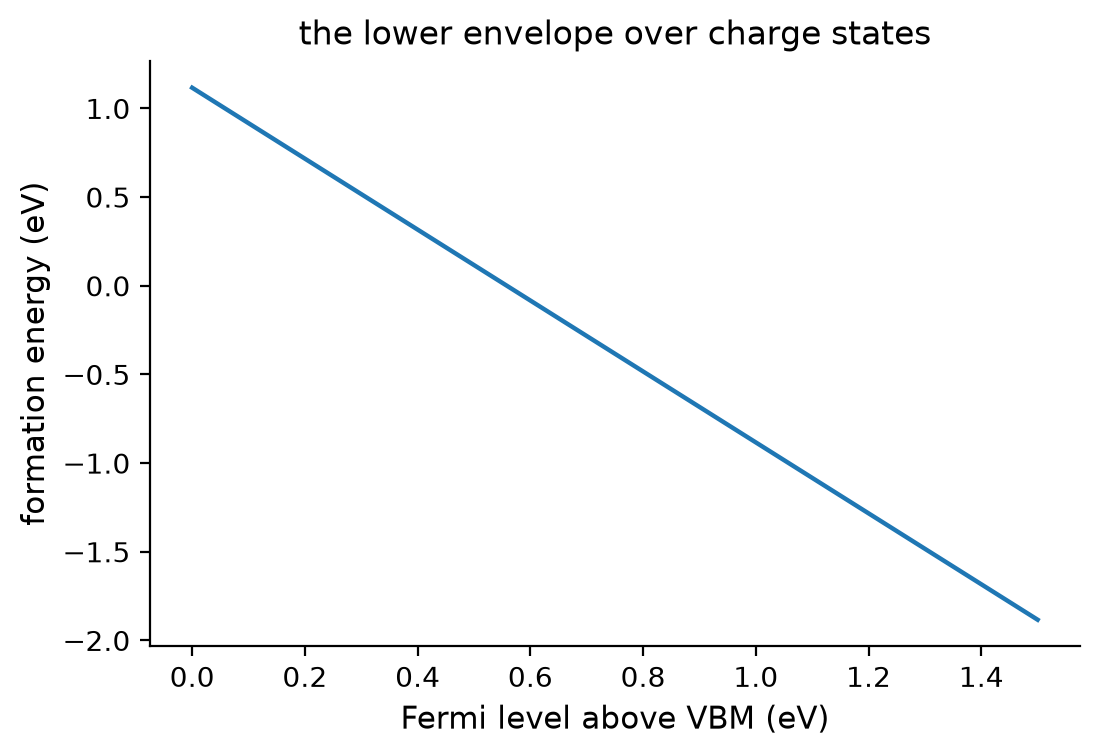

In [12]:
import matplotlib.pyplot as plt

fermi = mv.grid_of(defects, "formation_vs_fermi")
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(fermi, defects.obsm["formation_vs_fermi_emt"][0], linewidth=1.6)
ax.set_xlabel("Fermi level above VBM (eV)")
ax.set_ylabel("formation energy (eV)")
ax.set_title("the lower envelope over charge states")

In [13]:
defects.obs[["defect", "defect_formation_energy_emt",
             "stable_charge_emt"]].round(3)

,defect,defect_formation_energy_emt,stable_charge_emt
0,vacancy,1.117,-2


Each straight segment is one charge state, and its slope is the charge; the
kinks are the transition levels where the stable charge changes. `stable_charge`
records which state wins where.

The reported 1.117 eV is *not* the 1.314 eV computed by hand above, and the
difference is the point: 1.314 eV is the neutral vacancy, while this is the lower
envelope over all five charge states evaluated at the Fermi level. They coincide
only where the neutral state is the stable one.

```{warning}
Copper is a metal, so a band gap of 1.5 eV is fiction and the charged states are
meaningless here — this is the machinery, exercised on the only material EMT can
run. Use it on the oxides and halides where a Fermi level means something.

`mv.thermo.defect_formation` **warns and returns NaN** when no chemical
potential is given, rather than assuming one. A defect creates or destroys
atoms, and what they cost is not derivable from the defective cell.
```

### The charged states are lying, and by how much

Everything above ignores that a charged defect in a periodic cell interacts with
its own images. That interaction stabilises it spuriously, and in a small
supercell the error is tenths of an eV — enough to move a transition level and
change which charge state looks stable.

Pass a dielectric constant and the electrostatic half of the Freysoldt
correction is applied. It needs only the cell, the charge and epsilon — no
LOCPOT, no extra run:

In [14]:
import numpy as np

uncorrected = defects.copy()
mv.thermo.defect_formation(uncorrected, host=copper, level="emt",
                           chempot={"Cu": -3.5}, band_gap=1.5)

corrected = defects.copy()
mv.thermo.defect_formation(corrected, host=copper, level="emt",
                           chempot={"Cu": -3.5}, band_gap=1.5, dielectric=10.0)

grid = mv.grid_of(corrected, "formation_vs_fermi")
a = uncorrected.obsm["formation_vs_fermi_emt"][0]
b = corrected.obsm["formation_vs_fermi_emt"][0]

for target in (0.0, 0.75, 1.5):
    i = int(np.argmin(abs(grid - target)))
    print(f"E_F = {grid[i]:.2f} eV   uncorrected {a[i]:8.4f}   "
          f"corrected {b[i]:8.4f}   shift {b[i] - a[i]:+.4f}")

E_F = 0.00 eV   uncorrected  -2.3763   corrected  -2.3763   shift +0.0000
E_F = 0.75 eV   uncorrected  -3.8839   corrected  -2.8476   shift +1.0362
E_F = 1.50 eV   uncorrected  -5.3763   corrected  -4.2465   shift +1.1299


Zero shift at the valence band maximum and a growing one across the gap, which
is exactly right: at the VBM every charge state costs the same, so the neutral
one wins and has no image charge to correct. Further up, charged states take
over and each is corrected by its own $q^2$ term.

The correction scales as $q^2/(\epsilon L)$ — three things you can check rather
than trust. Double epsilon and it halves; go from a 2×2×2 to a 3×3×3 supercell
and it falls by 3/2; set $q=0$ and it vanishes. All three are asserted in the
test suite.

```{note}
That is **half** of the Freysoldt correction. The other half is a
potential-alignment term computed from the planar-averaged electrostatic
potential of both the defective and the pristine cell — a LOCPOT. Pass
`locpots=` and matverse applies it too;
`uns['defect_thermodynamics']['correction_terms']` says which terms a given run
actually used, and `['potential_alignment']` is a plain boolean.
```

The mapping is keyed by row name and covers both the defect rows and the host
rows they name in `obs['parent']`, so nothing extra has to be threaded through.
Values may be paths or `Locpot` objects.

```python
mv.thermo.defect_formation(
    defective, host, level="pbe", dielectric=11.7,
    locpots={"V_Si-0": "runs/vac/LOCPOT", "Si-bulk": "runs/bulk/LOCPOT"},
)
```

The alignment enters as $q\,\Delta V$, so it is exactly linear in a rigid shift
of either potential and vanishes at $q=0$. That is what makes it checkable
without a real LOCPOT, and the suite checks it: shift one potential by 0.5 eV
and every charge state moves by exactly $q 	imes 0.5$ eV.

Finding the defect site is done by comparing the two cells rather than with
pymatgen's `DefectSiteFinder`, which fits a SOAP descriptor and needs dscribe —
a package that cannot import at all on numpy ≥ 2.5. For a vacancy, an
interstitial or a substitution the two cells correspond one-to-one apart from
the defect, so matching sites by position answers it directly.

## What it costs to move

Formation says how many vacancies there are. Migration says how fast they move,
and the two together give the diffusion coefficient.

`mv.neb.hop_endpoints` builds the two ends of a hop: a vacancy, and the same
cell with a neighbour moved into it.

In [15]:
mv.neb.hop_endpoints(copper, species="Cu", supercell=(2, 2, 2))

copper.obs[["hop_distance", "hop_species"]].round(4)

,hop_distance,hop_species
0,2.5561,Cu


2.556 Å is the nearest-neighbour distance in copper, `a/√2`, which is what a
vacancy hop in fcc actually is.

```{warning}
Getting that number right is the whole calculation. The destination has to be the
nearest periodic **image** of the vacancy, not the coordinates as stored. Using
the stored ones sent the atom the long way round the cell — 7.66 Å instead of
2.55 — and the NEB then measured the cost of dragging an atom straight through
its neighbours, giving barriers of 5–7 eV. It looked like a physics result.

`hop_endpoints` now checks that the distance travelled matches the distance
reported and raises if they disagree.
```

Both endpoints need relaxing, and they need relaxing **separately** — a NEB needs
two distinct minima.

In [16]:
mv.calc.relax(copper, level="emt", source="hop_initial", key_added="start",
              fmax=0.05, steps=80, cell=False)
mv.calc.relax(copper, level="emt", source="hop_final", key_added="end",
              fmax=0.05, steps=80, cell=False)

mv.variants(copper)

['input',
 'supercell_2x2x2',
 'strained',
 'relaxed_emt',
 'hop_initial',
 'hop_final',
 'start',
 'end']

`key_added` matters here. Without it the second relaxation would overwrite the
first and the band would run from a structure to itself.

`cell=False` again, and for a second reason on top of the dilute-defect one: a
band is interpolated between two endpoints, and endpoints with different
lattices are not two points on one path.

## The nudged elastic band

In [17]:
mv.neb.barrier(copper, initial="start", final="end", level="emt",
               n_images=7, fmax=0.05, steps=200)

copper.obs[["barrier_emt", "barrier_reverse_emt", "reaction_energy_emt",
            "neb_converged_emt"]].round(4)

,barrier_emt,barrier_reverse_emt,reaction_energy_emt,neb_converged_emt
0,0.7544,0.7544,-0.0,True


**0.754 eV against a literature value of about 0.70 eV.** For a potential that
took no download and no training set, that is a genuinely useful number.

```{note}
The band uses the **improved-tangent** formulation of Henkelman and Jónsson
(2000), not ASE's default. ASE's own warning describes that default as "an
unpublished, custom implementation ... not recommended as it frequently results
in very poor bands", which is not something to leave on and hope for.
```

Two internal checks come free with a symmetric hop: forward and reverse barriers
must agree, and the reaction energy must be zero. Both hold to 0.02 eV. If they
did not, the band had not converged and the barrier would be an artefact —
worth reading every time, because a NEB that has not converged still reports a
number.

Text(0, 0.5, 'energy relative to start (eV)')

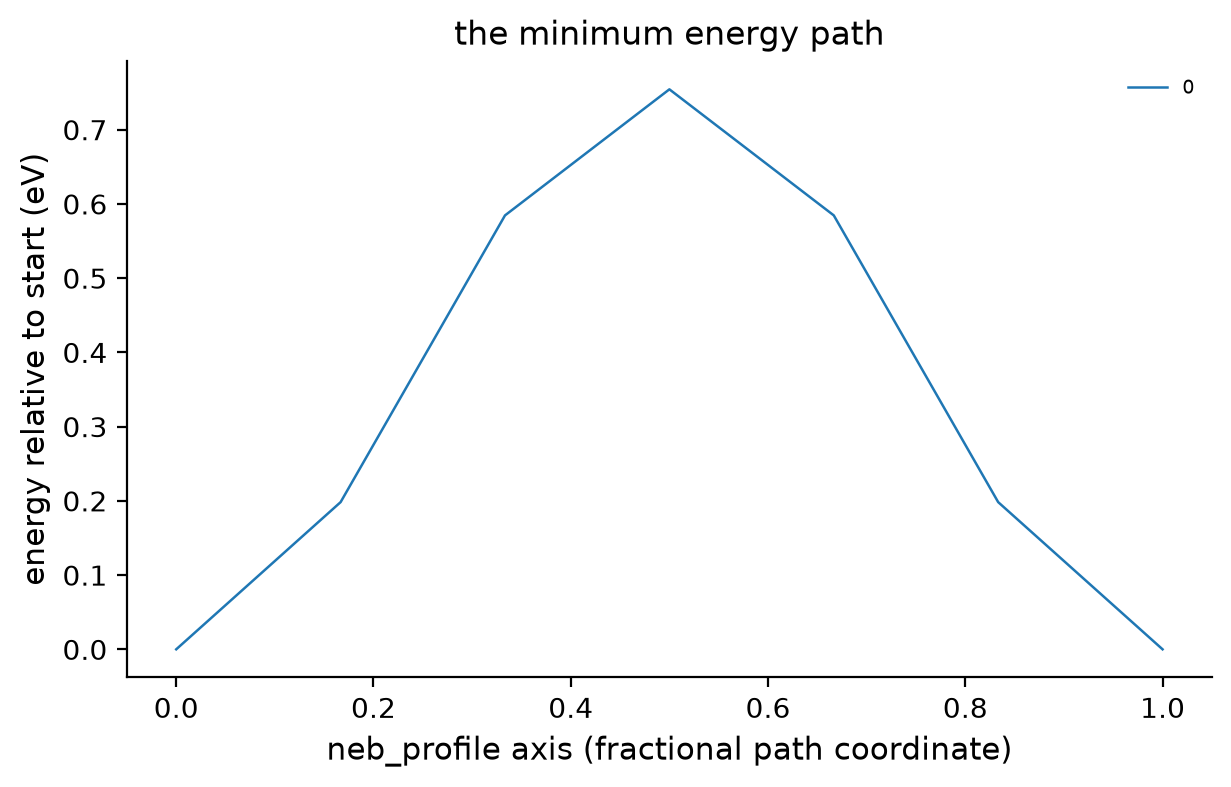

In [18]:
ax = mv.pl.spectra(copper, "neb_profile", levels=("emt",), rows=[0])
ax.set_title("the minimum energy path")
ax.set_ylabel("energy relative to start (eV)")

The path rises to a single saddle and comes back down, which is what a
single-hop mechanism looks like. A profile with two humps means an intermediate
minimum and a mechanism you have not modelled.

```{note}
The default interpolation is **IDPP**, not linear. Linear interpolation moves
every atom along a straight line in Cartesian space, which drives the hopping
atom directly through its neighbours; the band then has to climb out of that,
and often does not. IDPP interpolates interatomic distances instead.
```

## From a barrier to a diffusion coefficient

The two numbers combine in the classical way — a jump attempt at the Debye
frequency, times the probability of clearing the barrier, times the probability
that a neighbouring site is vacant.

In [19]:
kB = 8.617333e-5                       # eV/K
nu = 1e13                              # attempt frequency, s^-1
a = float(copper.obs["hop_distance"].iloc[0]) * 1e-10     # m
barrier = float(copper.obs["barrier_emt"].iloc[0])

T = np.array([300.0, 500.0, 800.0, 1000.0, 1300.0])
c_vac = np.exp(-formation / (kB * T))
D = a ** 2 * nu * c_vac * np.exp(-barrier / (kB * T))

pd.DataFrame({"T (K)": T, "vacancy fraction": c_vac, "D (m^2/s)": D})

,T (K),vacancy fraction,D (m^2/s)
0,300.0,8.553908e-23,1.187142e-41
1,500.0,5.745115e-14,9.349030e-28
2,800.0,5.303490e-09,6.129359e-20
3,1000.0,2.396897e-07,2.471522e-17
4,1300.0,8.080209e-06,6.281844e-15


Text(0.5, 1.0, 'Arrhenius: the slope is formation + migration')

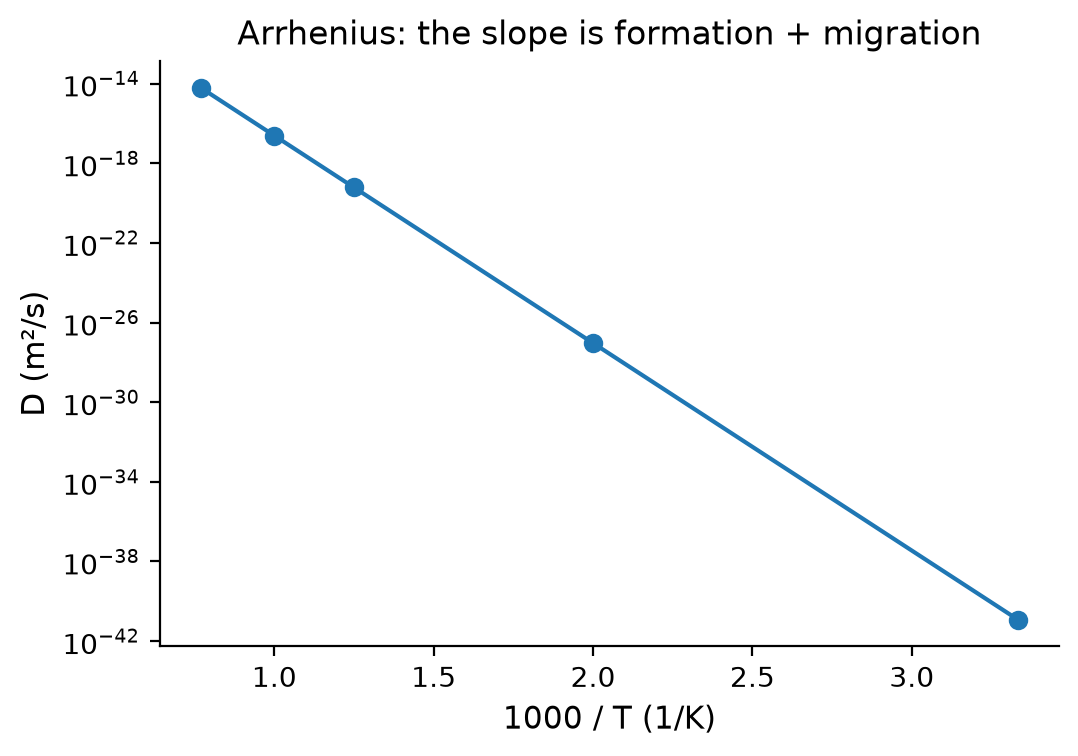

In [20]:
fig, ax = plt.subplots(figsize=(5.8, 3.8))
ax.semilogy(1000 / T, D, "o-")
ax.set_xlabel("1000 / T (1/K)")
ax.set_ylabel("D (m²/s)")
ax.set_title("Arrhenius: the slope is formation + migration")

A straight line on this plot is the definition of Arrhenius behaviour, and its
slope is the **sum** of the two energies — which is why a measured activation
energy alone cannot tell you whether a material diffuses quickly because
vacancies are cheap or because they are mobile. Computing them separately can.

At 1300 K, just under copper's melting point of 1358 K, this gives 1×10⁻¹⁴ m²/s
against a measured self-diffusion coefficient of order 10⁻¹³ — within an order
of magnitude, from two energies each good to about 10%, which is what
exponentiating small errors does to you.

At room temperature it is 10⁻⁴⁰ m²/s: twenty-six orders of magnitude slower, and
the reason a copper wire does not visibly age. The vacancy fraction alone falls
from 10⁻⁵ to 10⁻²¹ over that range.

## Which barriers are actually worth computing?

The NEB above was one hop, chosen for us by `mv.neb.hop_endpoints`. A real cell
has many pairs of mobile sites and far fewer *kinds* of jump between them —
running a band for each pair spends almost the whole budget re-deriving barriers
that symmetry already fixed.

`mv.neb.hops` enumerates the distinct ones:

In [21]:
from pymatgen.core import Lattice, Structure

lattices = mv.data.from_structures([
    Structure(Lattice.cubic(3.51), ["Li"] * 4,
              [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]]),
    Structure.from_spacegroup("Fd-3m", Lattice.cubic(8.24), ["Li", "Mn", "O"],
                              [[0, 0, 0], [0.625] * 3, [0.3875] * 3])])
lattices.obs_names = ["Li fcc", "LiMn2O4 spinel"]

distinct = mv.neb.hops(lattices, species="Li")
distinct.obs[["parent", "hop_distance", "multiplicity"]].round(4)

,parent,hop_distance,multiplicity
0,Li fcc,2.4819,24
1,LiMn2O4 spinel,3.5680,16


One hop each. Close-packed lithium has twelve neighbours and they are all the
same neighbour as far as symmetry is concerned, so **one** band gives you all
twelve — 2.482 Å is $a/\sqrt{2}$, and the multiplicity 24 is four sites times
twelve neighbours counted from both ends. Spinel's 8a sublattice is diamond-like:
3.568 Å is $a\sqrt{3}/4$ and each of the eight sites has four neighbours.

Break the symmetry and the hop splits, which is the behaviour that makes the
count worth trusting:

In [22]:
squashed = mv.data.from_structures([Structure(
    Lattice.tetragonal(3.51, 3.90), ["Li"] * 4,
    [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])])

split = mv.neb.hops(squashed, species="Li", cutoff=3.2)
split.obs[["hop_distance", "multiplicity"]].round(4)

,hop_distance,multiplicity
0,2.4819,8
1,2.6235,16


Stretching *c* separates the twelve neighbours into four in the basal plane at
$a/\sqrt{2}$ and eight out of it at $\sqrt{a^2+c^2}/2$. Two kinds of jump now,
two barriers to compute, and the multiplicities still sum to 24 — nothing was
lost, it was reclassified.

```{note}
Distinctness here means "same pair of symmetry-equivalent sites, same distance
to within `tol`". That is exact when the site pair and the length determine the
path, which covers ordinary crystals. In a low-symmetry cell it can merge two
genuinely different routes between the same pair of sites — it never splits what
should be merged, so the count is a lower bound on the work, never an inflated
one.

Written from the definition rather than wrapped from
`pymatgen.analysis.diffusion.neb.full_path_mapper`, whose `MigrationGraph` calls
a `StructureGraph` method that was renamed upstream and raises `AttributeError`
against current pymatgen.
```

## Before the barrier: can the ion get out at all?

A barrier is the cost of **one** hop. It is silent on whether that hop repeated
ever carries an ion across the crystal. A material can have a beautifully low
barrier between two sites that form a closed pair and conduct precisely nothing,
and no amount of NEB will tell you so — the calculation you ran was about those
two sites.

`mv.neb.percolation` asks the other question, and asks it from geometry alone,
so it costs nothing and can run first. Starting from one mobile site, which
periodic *images of that same site* can be reached by hops no longer than the
cutoff? Reaching a different site one cell over only says two sites are
connected. Reaching your own site in the next cell says the network repeats —
the ion can keep going.

The two canonical lithium cathodes make the point:

In [23]:
from pymatgen.core import Lattice, Structure

# Fd-3m in pymatgen is origin choice 1, so the tetrahedral 8a site is at the
# origin, not at (1/8, 1/8, 1/8). Put Li at (1/8, 1/8, 1/8) here and you
# silently build Li2MnO4 on a 16-fold site instead of spinel.
spinel = Structure.from_spacegroup(
    "Fd-3m", Lattice.cubic(8.24), ["Li", "Mn", "O"],
    [[0, 0, 0], [0.625] * 3, [0.3875] * 3])
layered = Structure.from_spacegroup(
    "R-3m", Lattice.hexagonal(2.82, 14.05), ["Li", "Co", "O"],
    [[0, 0, 0], [0, 0, 0.5], [0, 0, 0.2395]])

cathodes = mv.data.from_structures([spinel, layered])
cathodes.obs_names = ["LiMn2O4", "LiCoO2"]
cathodes.obs["formula"] = [s.composition.reduced_formula
                           for s in mv.structures(cathodes, "input")]

mv.neb.percolation(cathodes, species="Li", cutoff=3.6)
cathodes.obs[["formula", "percolation_sites_Li",
              "percolation_dimensionality_Li",
              "percolation_threshold_Li"]].round(3)

,formula,percolation_sites_Li,percolation_dimensionality_Li,percolation_threshold_Li
LiMn2O4,LiMn2O4,8,3,3.568
LiCoO2,LiCoO2,3,2,2.820


**3 against 2**, which is the textbook difference between the two: spinel
conducts lithium in three dimensions through a network of corner-sharing
tetrahedral sites, and a layered oxide conducts it only within the planes
between the CoO₂ slabs. Both percolate; only one of them percolates everywhere.

The thresholds are exact geometry — 3.568 Å is a·√3/4, the nearest-neighbour
distance on spinel's diamond-like 8a sublattice, and 2.820 Å is simply the
hexagonal *a* of the layered cell. That is the bottleneck hop: the shortest
length at which anything percolates at all, and the one the ion cannot avoid.

Now the part worth being careful about. Dimensionality is a property of the
network **at a hop length**, not a property of the material:

In [24]:
for cutoff in (2.5, 3.0, 3.6, 5.0):
    mv.neb.percolation(cathodes, species="Li", cutoff=cutoff,
                       key_added=f"at_{cutoff}")

cathodes.obs[["formula"] + [f"percolation_dimensionality_at_{c}"
                            for c in (2.5, 3.0, 3.6, 5.0)]]

,formula,percolation_dimensionality_at_2.5,percolation_dimensionality_at_3.0,percolation_dimensionality_at_3.6,percolation_dimensionality_at_5.0
LiMn2O4,LiMn2O4,0,0,3,3
LiCoO2,LiCoO2,0,2,2,3


Allow a 5 Å hop and the layered oxide becomes three-dimensional too, because
that is long enough to jump the slab. The answer did not change; the question
did. Quoting a dimensionality without the hop length it was measured at is
quoting half a result — which is why the cutoff is recorded in
`uns['percolation']` alongside it.

Read this as a filter, not a verdict. A percolating network is a **necessary**
condition for conduction and never a sufficient one: it says the geometry does
not forbid transport, and says nothing about what it costs. That is what the
barrier above is for. Run percolation on a thousand candidates in seconds, then
spend the NEB budget on the ones that survive.

## Handing the hop to DFT

EMT gave a barrier worth having for copper. When it is not enough — a transition
metal, an oxide, anything where a universal potential softens the surface — the
endpoints above are already the two structures a DFT NEB needs, and
`mv.dft.write_inputs` has a preset for exactly that job:

In [25]:
paths = mv.dft.write_inputs(copper, "runs/neb", preset="neb-endpoint",
                            source="hop_initial")

from pathlib import Path
incar = (Path(paths[0]) / "INCAR").read_text()
print("\n".join(line for line in incar.splitlines()
                 if line.split("=")[0].strip() in
                 ("ISIF", "ISYM", "IBRION", "EDIFFG", "NSW")))

EDIFFG = -0.02
IBRION = 2
ISIF = 2
ISYM = 0
NSW = 99


Two of those settings are the reason to use a preset rather than write the file
by hand. **ISIF = 2** holds the cell fixed: relax the cell at each end
independently and the two endpoints are no longer the same system, so the
energy difference between them stops meaning anything. **ISYM = 0** turns
symmetry off, without which VASP will happily symmetrise the displaced atom back
where it started and hand you a barrier for a hop that did not happen.

These come from `MVLCINEBEndPointSet`, the VTST-tested settings in
`pymatgen-analysis-diffusion`. Write the inputs, run them wherever you run VASP,
and `mv.dft.read_outputs` brings the energies back onto the same rows.

## Finding a defect somebody else made

`mv.pp.defects` puts defects where it chooses and remembers. The other
direction is commoner: a relaxed supercell arrives from someone else's
calculation, the defect is wherever it ended up, and the neighbours have moved
in around it. Subtracting site lists does not work — they are ordered
differently and everything has shifted.

`mv.pp.locate_defect` finds it from the local environment instead:

In [26]:
# 3x3x3, not 2x2x2: the descriptor this uses has a 5 A cutoff, and a cell
# shorter than 10 A lets every site see the defect through its own periodic
# images. matverse warns when that happens, because the answer is wrong
# without looking wrong.
perfect = mv.structures(copper, "input")[0].copy()
perfect.make_supercell([3, 3, 3])
damaged = perfect.copy()
removed_at = perfect[13].frac_coords
damaged.remove_sites([13])

# reverse the site order, as a foreign file might well arrive
from pymatgen.core import Structure
shuffled = Structure.from_sites(list(damaged.sites)[::-1])

hunt = mv.data.from_structures([shuffled])
try:
    mv.pp.locate_defect(hunt, host=mv.data.from_structures([perfect]))
    result = hunt.obs[["defect_a", "defect_b", "defect_c",
                       "defect_nearest_site"]].round(4)
    print("removed at:", removed_at.round(4))
except ImportError as exc:
    result = str(exc)[:200]      # dscribe is an optional extra
result

'mv.pp.locate_defect needs pymatgen-analysis-defects and dscribe. dscribe imports sparse, which imports numba, which requires numpy < 2.5 — on a newer numpy the install resolves and the import does not'

The vacancy comes back at the coordinates it was made at, from a cell whose
sites are in the opposite order.

```{warning}
**Use a big enough supercell.** The descriptor underneath has a hard-coded 5 Å
cutoff, so a cell shorter than 10 Å along any axis lets every site see the
defect through its own periodic images — none looks distinctly perturbed, and
the position comes back wrong without anything looking wrong. 2×2×2 fcc copper
misses by 3.5 Å. matverse warns when the cell is too small; 3×3×3 and larger are
exact.

Needs **dscribe**, which imports `sparse`, which imports `numba`, which requires
numpy below 2.5. On a newer numpy the install resolves and the import does not,
so the cell above catches that rather than failing the tutorial.
```

## The curve a charge state leaves behind

When a defect changes charge, its neighbours move to a new equilibrium. The
energy along that displacement is the configuration-coordinate curve, and two
numbers come off it: the **curvature** gives an effective phonon frequency, and
the height at the *other* state's geometry gives the **relaxation energy** —
what gets dumped into the lattice when the charge changes.

Those two are exactly what the capture coefficient below needs, and nothing in
matverse produced them until now:

In [27]:
import numpy as np

# stand-in for energies computed along an interpolation between two relaxed
# charge states; Q is mass-weighted, in amu^(1/2) angstrom
Q = np.linspace(-2.0, 2.0, 21)
curvature, offset = 0.6, 1.5

curve = mv.data.from_structures(mv.structures(copper, "input") * len(Q))
curve.obs["Q"] = Q
curve.obs["energy_pbe"] = 0.5 * curvature * (Q - offset) ** 2

mv.prop.configuration_coordinate(curve, coordinate="Q", level="pbe")
curve.uns["configuration_coordinate"]["pbe"]

{'frequency_eV': 0.0500808799474792,
 'relaxation_energy_eV': 0.6749999999999996,
 'huang_rhys': 13.47819768158797,
 'curvature': 0.5999999999999995,
 'minimum_at': 1.5,
 'n_points': 21,
 'coordinate_unit': 'amu^(1/2) angstrom',
 'note': 'Huang-Rhys above about five strains the one-dimensional harmonic picture; read what follows as order-of-magnitude'}

The frequency is $\hbar\sqrt{c}$ with the mass-weighted units carried
through — 0.050 eV here, about 400 cm⁻¹, an ordinary optical phonon. The
relaxation energy is $\tfrac{1}{2}c\,\Delta Q^2$, which for this offset is
0.675 eV.

**Huang–Rhys** is the ratio: how many phonons the relaxation is worth. Above
about five, a one-dimensional harmonic picture is carrying more than it should,
and anything computed from it is order-of-magnitude.

```{note}
Mass-weighting is not optional. The same displacement of a hydrogen and of a
bismuth are not the same coordinate, and an unweighted fit returns a number that
is not a frequency.

Fitted here rather than wrapped: pymatgen's `HarmonicDefect` takes the frequency
as an *input* rather than fitting it, and the fit lives in a private helper
reachable only through `from_vaspruns`. The test suite checks this agrees with
`HarmonicDefect.omega_eV` to 1e-7.
```

## Is it a killer?

A defect level in the gap is not automatically a problem. What decides whether
it ruins a solar cell is how fast it captures carriers, and that turns on how
far the lattice relaxes when the charge state changes — a deep level with little
relaxation is harmless, and a shallow one with a lot is not.

`mv.prop.capture` gives the Shockley–Read–Hall coefficient in the
one-dimensional configuration-coordinate approximation:

In [28]:
traps = mv.data.from_structures(mv.structures(copper, "input") * 2)
traps.obs_names = ["weakly coupled", "strongly coupled"]

mv.prop.capture(traps, dQ=1.0, dE=1.0, omega_i=0.02, omega_f=0.02,
                coupling=[1e-3, 2e-3], temperature=300.0)

traps.obs[["capture_coefficient_srh"]]

Numba not installed. Install Numba for better performance.


,capture_coefficient_srh
weakly coupled,4.525112e-17
strongly coupled,1.810045e-16


Doubling the electron–phonon matrix element multiplies the capture rate by
**four** — it enters squared — so a factor of two in a quantity nobody computes
very precisely is a factor of four in the answer. Worth knowing before ranking
defects on it.

It is also thermally activated, steeply:

In [29]:
for T in (200.0, 300.0, 600.0):
    mv.prop.capture(traps, dQ=1.0, dE=1.0, omega_i=0.02, omega_f=0.02,
                    coupling=1e-3, temperature=T, key_added=f"T{int(T)}")

traps.obs[[f"capture_coefficient_T{int(T)}"
           for T in (200, 300, 600)]].iloc[[0]]

,capture_coefficient_T200,capture_coefficient_T300,capture_coefficient_T600
weakly coupled,2.223054e-19,4.525112e-17,1.926414e-13


Orders of magnitude across a few hundred kelvin, which is why a capture
coefficient quoted without its temperature is not a quantity. The temperature
is stored in `uns['capture']` beside every column.

```{note}
**The configuration-coordinate parameters are arguments.** dQ is the
mass-weighted displacement between the two relaxed charge states, dE their
separation, omega_i and omega_f the two harmonic frequencies, and `coupling` the
electron–phonon matrix element — all from a calculation matverse does not do.
Only the cell volume is taken from the structure, because that is the one thing
already here.

`kind='radiative'` switches to the radiative channel, where `coupling` is read
as a dipole matrix element. Ask for a photon more energetic than the transition
and matverse refuses: pymatgen returns NaN for that case without comment, which
would arrive as a silently blank column.
```

## What the object remembers

In [30]:
for step in mv.provenance(copper):
    print(step)

data.from_structures
pp.describe(source='input')
pp.supercell(scaling=(2, 2, 2), source='input', name='supercell_2x2x2')
pp.strain(source='input', name='strained')
calc.relax(level='emt', source='input', fmax=0.02, cell=True, key_added='relaxed_emt')
thermo.chempot_limits(level='emt', n_stable=1)
neb.hop_endpoints(species='Cu', source='input', supercell=[2, 2, 2], key_added='hop')
calc.relax(level='emt', source='hop_initial', fmax=0.05, cell=False, key_added='start')
calc.relax(level='emt', source='hop_final', fmax=0.05, cell=False, key_added='end')
neb.barrier(level='emt', initial='start', final='end', n_images=7)
dft.write_inputs(preset='neb-endpoint', source='hop_initial', n_written=1)


```{seealso}
[Surfaces and adsorption](surfaces_and_adsorption.ipynb) does the same thing for
the other place atoms move — the surface. [Dynamics](dynamics.ipynb) reaches
diffusion the other way, by simply watching atoms move.
```